In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('Walmart_Store_sales.csv')
print(df.head())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [6]:
# converting date column to datetime
df['Date']= pd.to_datetime(df['Date'],dayfirst=True)

df = df.sort_values('Date')

print(df.head())

      Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0         1 2010-02-05    1643690.90             0        42.31       2.572   
1287     10 2010-02-05    2193048.75             0        54.34       2.962   
5148     37 2010-02-05     536006.73             0        45.97       2.572   
2288     17 2010-02-05     789036.02             0        23.11       2.666   
4147     30 2010-02-05     465108.52             0        39.05       2.572   

             CPI  Unemployment  
0     211.096358         8.106  
1287  126.442065         9.765  
5148  209.852966         8.554  
2288  126.442065         6.548  
4147  210.752605         8.324  


In [8]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 452.5 KB
None
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [10]:
sale_trends = df.groupby('Date')['Weekly_Sales'].sum()
print(sale_trends)

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
                 ...     
2012-09-28    43734899.40
2012-10-05    47566639.31
2012-10-12    46128514.25
2012-10-19    45122410.57
2012-10-26    45544116.29
Name: Weekly_Sales, Length: 143, dtype: float64


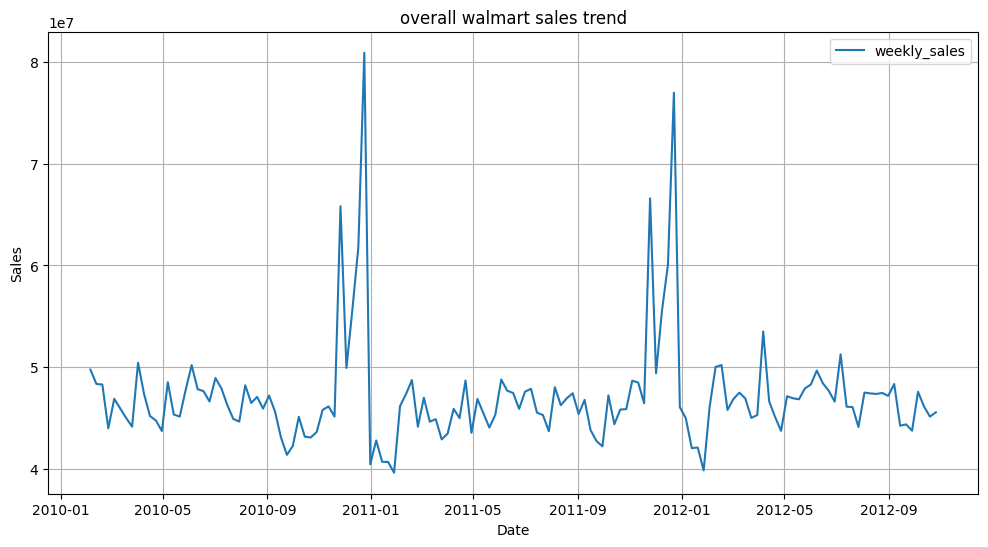

In [12]:
plt.figure(figsize=(12,6))
plt.plot(sale_trends,label = "weekly_sales")
plt.title("overall walmart sales trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.show()

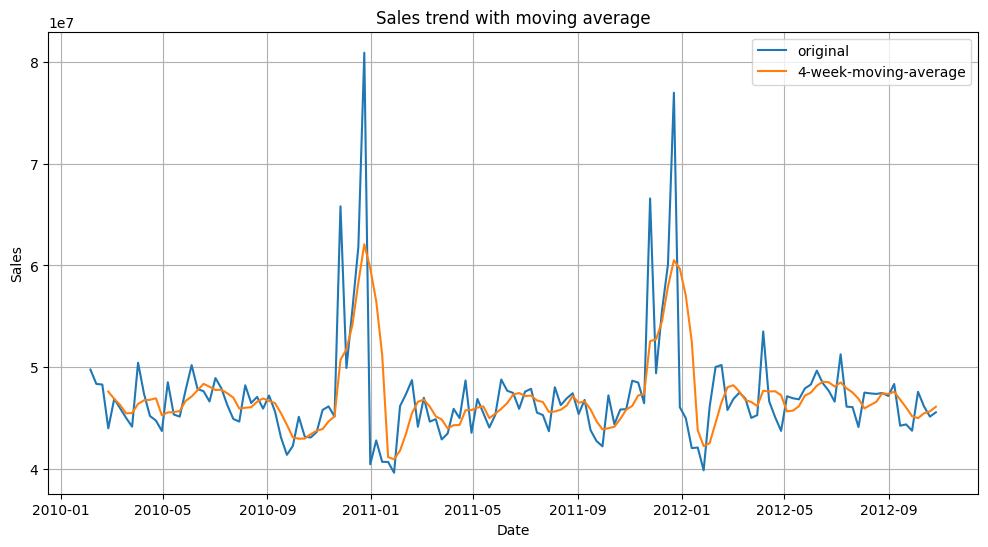

In [13]:
sale_trends_ma = sale_trends.rolling(window=4).mean()
plt.figure(figsize=(12,6))
plt.plot(sale_trends,label = "original")
plt.plot(sale_trends_ma,label = "4-week-moving-average")
plt.title("Sales trend with moving average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.show()


In [14]:
df['Month'] = df['Date'].dt.month
print(df.head())

      Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0         1 2010-02-05    1643690.90             0        42.31       2.572   
1287     10 2010-02-05    2193048.75             0        54.34       2.962   
5148     37 2010-02-05     536006.73             0        45.97       2.572   
2288     17 2010-02-05     789036.02             0        23.11       2.666   
4147     30 2010-02-05     465108.52             0        39.05       2.572   

             CPI  Unemployment  Month  
0     211.096358         8.106      2  
1287  126.442065         9.765      2  
5148  209.852966         8.554      2  
2288  126.442065         6.548      2  
4147  210.752605         8.324      2  


In [16]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].sum()
print(monthly_sales)

Month
1     3.325984e+08
2     5.687279e+08
3     5.927859e+08
4     6.468598e+08
5     5.571256e+08
6     6.226299e+08
7     6.500010e+08
8     6.130902e+08
9     5.787612e+08
10    5.847848e+08
11    4.130157e+08
12    5.768386e+08
Name: Weekly_Sales, dtype: float64


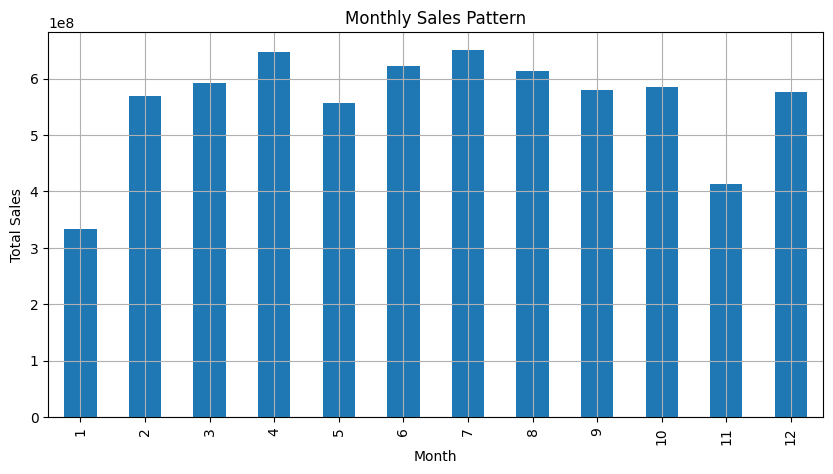

In [17]:
monthly_sales.plot(kind='bar', title='Monthly Sales Pattern', figsize=(10,5))
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid()
plt.show()

In [20]:
holiday_sales = df[df['Holiday_Flag']==1]["Weekly_Sales"]
non_holiday_sales = df[df['Holiday_Flag']==0]['Weekly_Sales']

C:\Users\hamma\AppData\Local\Temp\ipykernel_14412\635942173.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([non_holiday_sales, holiday_sales], labels=['Non-Holiday', 'Holiday'])


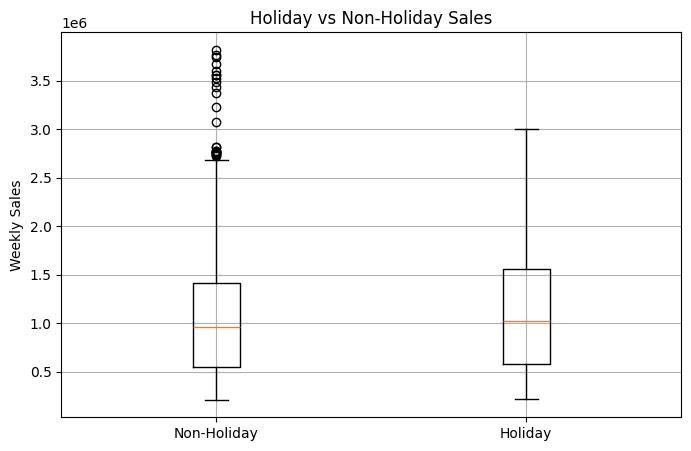

In [21]:
plt.figure(figsize=(8,5))
plt.boxplot([non_holiday_sales, holiday_sales], labels=['Non-Holiday', 'Holiday'])
plt.title("Holiday vs Non-Holiday Sales")
plt.ylabel("Weekly Sales")
plt.grid()
plt.show()

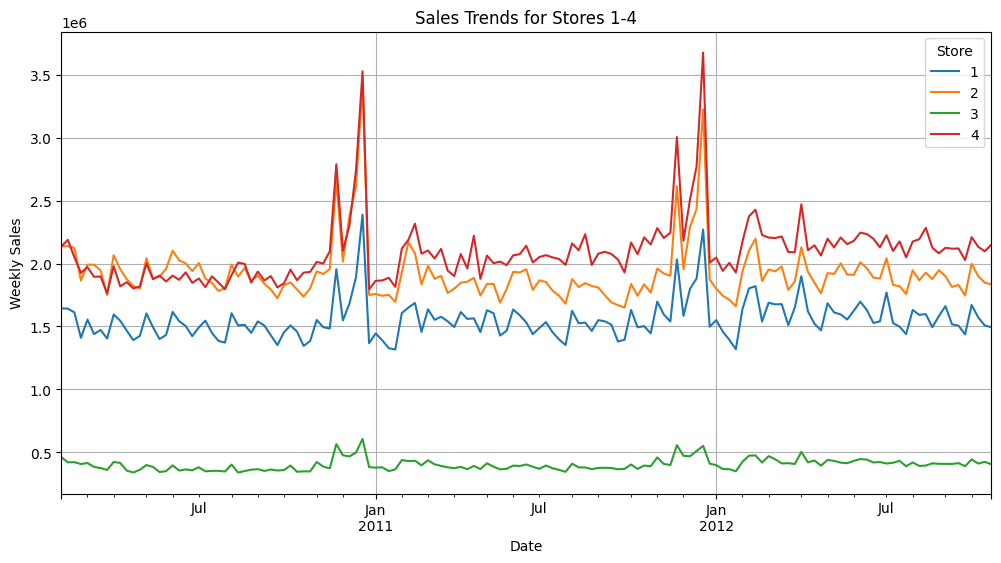

In [22]:
store_sales = df.groupby(["Date","Store"])["Weekly_Sales"].sum().unstack()
store_sales[[1,2,3,4]].plot(figsize=(12,6))
plt.title("Sales Trends for Stores 1-4")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend(title="Store")
plt.grid()
plt.show()

In [23]:
correlation = df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].corr()
print(correlation)


              Weekly_Sales  Temperature  Fuel_Price       CPI  Unemployment
Weekly_Sales      1.000000    -0.063810    0.009464 -0.072634     -0.106176
Temperature      -0.063810     1.000000    0.144982  0.176888      0.101158
Fuel_Price        0.009464     0.144982    1.000000 -0.170642     -0.034684
CPI              -0.072634     0.176888   -0.170642  1.000000     -0.302020
Unemployment     -0.106176     0.101158   -0.034684 -0.302020      1.000000
